# SVM - primer primene nad realnim podacima

Koristimo skup podataka [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)).

In [1]:
from sklearn.datasets import load_breast_cancer

In [2]:
X, y = load_breast_cancer(return_X_y=True)

In [3]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [4]:
X.shape

(569, 30)

Delimo skup podataka na trening i test skup.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=123)

In [7]:
X_train.shape

(426, 30)

In [8]:
X_test.shape

(143, 30)

Vršimo standardizaciju ulaznih atributa.

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [12]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Za sledeće kombinacije hiperparametara obučavamo *SVM* model.

In [13]:
params = [
            {
                'kernel': ['linear'],               #hiperparametari za linearni SVM
                'C': [0.01, 0.1, 1, 10],
            },
            {
                'kernel': ['rbf'],                  #hiperparametri za kernelizovani SVM
                'C': [0.01, 0.1, 1, 10],
                'gamma': [0.01, 0.1, 1, 10],
            },
         ]

Zašto _params_ nije jedna obična mapa? Kada želimo dva podskupa kombinacija vrednosti hiperparametara pravimo listu mapa, po jednu mapu za svaki podskup kombinacija.

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [15]:
gs = GridSearchCV(SVC(), params, scoring='accuracy', cv=5, verbose=5)

In [16]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END .............C=0.01, kernel=linear;, score=0.930 total time=   0.0s
[CV 2/5] END .............C=0.01, kernel=linear;, score=0.976 total time=   0.0s
[CV 3/5] END .............C=0.01, kernel=linear;, score=0.953 total time=   0.0s
[CV 4/5] END .............C=0.01, kernel=linear;, score=0.953 total time=   0.0s
[CV 5/5] END .............C=0.01, kernel=linear;, score=0.988 total time=   0.0s
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.942 total time=   0.0s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.988 total time=   0.0s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.976 total time=   0.0s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.976 total time=   0.0s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=1.000 total time=   0.0s
[CV 1/5] END ................C=1, kernel=linear;, score=0.953 total time=   0.0s
[CV 2/5] END ................C=1, kernel=linear

,estimator,SVC()
,param_grid,"[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'gamma': [0.01, 0.1, ...], 'kernel': ['rbf']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


Njbolja kombinacija vrednosti hiperparametara i njemu odgovarajući skor modela:

In [17]:
gs.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [18]:
gs.best_score_

0.9789603283173735

Evaluiramo najbolji model na test skupu.

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

In [20]:
y_test_pred = gs.best_estimator_.predict(X_test)

In [21]:
accuracy_score(y_test, y_test_pred)

0.9790209790209791

In [22]:
confusion_matrix(y_test, y_test_pred)

array([[50,  3],
       [ 0, 90]])

In [23]:
f1_score(y_test, y_test_pred)

0.9836065573770492

Pokušajte da još poboljšate rezultate dodatnim podešavanjem hiperparametara

### Vizuelizacija

Iscrtavamo skup podataka zajedno sa istaknutim potpornim vekorima dobijenog modela. Kako bismo mogli da vizuelizujemo skup podataka, primenićemo *PCA* za redukciju na dve dimenzije.

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA(n_components=2)

In [26]:
pca.fit(X_train)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [27]:
X_train_pca = pca.transform(X_train)

In [28]:
import matplotlib.pyplot as plt

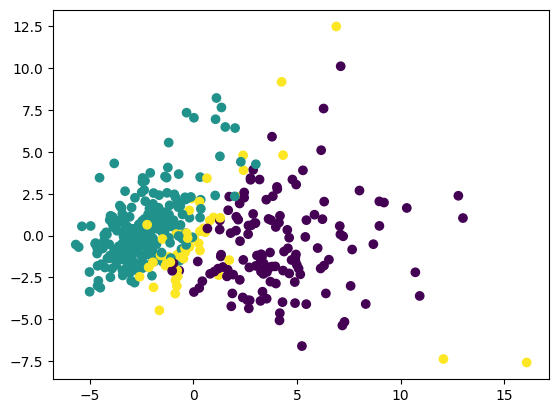

In [29]:
color = y_train.astype(int)    
color[gs.best_estimator_.support_] = 2  
    
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=color)
plt.show()   